# MJO 0: Overview

Example diagrams from [Physical Science Lab](psl.noaa.gov/mjo)
 <p align="center">
    <img src="https://preview.weather.gov/images/arx/lanina/MJO2.jpg">
</p>

 <p align="center">
    <img src="https://psl.noaa.gov/mjo/psl/mjo/images/mjo_global_impacts.jpg">
</p>"

## MJO 1: Obtain Daily Model Data/Output

Read in daily model output via `daily.netcdf.ncl`"

`MJO_suite.py` - Line 44 - "OBTAINING DAILY OUTPUT"
```
generate_ncl_plots(os.environ["POD_HOME"]+"/daily_netcdf.ncl")
```

`daily_netcdf.ncl` reads daily output files from CAM2 and processes the data (each daily file has 30 days of data) (for example: U200(time, lat, lon))

Configuration file: `input_NCEP_Reanalysis_1980_1990.jsonc` (Configuration for MDTF-diagnostics driver script)

Additional details: [see here](https://mdtf-diagnostics.readthedocs.io/en/latest/sphinx/dev_cheatsheet.html#notes)

In [14]:
# Variable-specific environment variables which are accessed with os.environ()
# CASENAME =  "NCEP_Reanalysis"
# startdate = ???? (string in YYYYMMDD or YYYYMMDDHHMMSS for starting period of analysis)
# enddate =   ???? (string in YYYYMMDD or YYYYMMDDHHMMSS for ending period of analysis)

## DATADIR =  "data/day" (created in MJO_suite if doesn't already exist, L40)
# WORK_DIR =  (working directory) 

# U200_FILE = ???? (data file for 200-hPa zonal wind at lower boundary level, eastward wind in the atmosphere in m/s, scalar-coordinates where atmosphere pressure level lev=200)
# U850_FILE = ???? (data file for 850-hPa zonal wind at higher boundary level, eastward wind in the amotphere in m/s, scalar-coordinates where atmosphere pressure level lev=850)
# V200_FILE = ???? (data file for 200-hPa meridional wind, northward wind in the atmosphere in m/s, scalar-coordaintes where lev=200)
# RLUT_FILE = ???? (data file for outgoing longwave radiation, aka: OLR)
# PR_FILE =   ????

# lev_coord =  ???? (name of the level dimension, e.g. air pressure hPa (postive down, z-axis)
# lat_coord =  ???? (name of the latitude dimension in the model's native format, e.g. latitude in degrees North, y-axis)
# lon_coord =  ???? (name of the longitude dimension in the model's native format, e.g. longitude in degrees East, x-axis)
# time_coord = ???? (name of the time dimension in the model's native format)
# pr_var =     ???? (name of precipitation rate, in m/s, with the dimensions = "time, "lat", "lon" -- retained for backwards compatibility -> absolute path to the file containing "pr" data, for example, "/dir/precip.nc")
# rlut_var =   ???? (TOA Outgoing longwave flux/radiation, in W/m^2, with the dimensions = "time", "lat", "lon")

# setting.jsonc
# v850 = northward wind in m/s, scalar-coordinates where atmospheric pressure level lev = 850

In [5]:
# # getenv == os.environ
import os

In [45]:
# read in from settings.jsonc
import json

def parse_json_with_comments(json_file=None):
    with open(json_file, "r") as file:
        lines = file.readlines()
    json_data = ""
    for line in lines:
        # remove comments
        line = line.split("//")[0].split("/*")[0].strip()
        json_data += line
    return json.loads(json_data)

settings_json = parse_json_with_comments("settings.jsonc")
settings_json

{'settings': {'driver': 'MJO_suite.py',
  'long_name': 'MJO diagnostics suite (from AMWG variability diagnostic package)',
  'convention': 'cesm',
  'description': 'MJO CLIVAR suite (NCAR)',
  'runtime_requirements': {'python3': [],
   'ncl': ['contributed',
    'gsn_code',
    'gsn_csm',
    'shea_util',
    'diagnostics_cam']}},
 'data': {'frequency': 'day'},
 'dimensions': {'lat': {'standard_name': 'latitude',
   'units': 'degrees_north',
   'axis': 'Y'},
  'lon': {'standard_name': 'longitude', 'units': 'degrees_east', 'axis': 'X'},
  'lev': {'standard_name': 'air_pressure',
   'units': 'hPa',
   'positive': 'down',
   'axis': 'Z'},
  'time': {'standard_name': 'time'}},
 'varlist': {'rlut': {'standard_name': 'toa_outgoing_longwave_flux',
   'realm': 'atmos',
   'units': 'W m-2',
   'dimensions': ['time', 'lat', 'lon']},
  'pr': {'standard_name': 'precipitation_rate',
   'realm': 'atmos',
   'units': 'm s-1',
   'dimensions': ['time', 'lat', 'lon']},
  'u200': {'standard_name': 'east

In [6]:
CASENAME = "NCEP_Reanalysis"
startdate = ''
enddate = ''

DATADIR = "data/day"
WORK_DIR = os.getcwd()

U200_FILE = ''
V200_FILE = ''
U850_FILE = ''
RLUT_FILE = ''
PR_FILE = ''

lev_coord = ''
lat_coord = ''
lon_coord = ''
time_coord = ''
pr_var = ''
rlut_var = ''

# setup data directory, if does not already exist
if not os.path.exists(DATADIR): os.makedirs(DATADIR)

In [ ]:
# collect time coordiantes


In [35]:
# check date format
from datetime import datetime

def check_date_format(date_in="", is_start=True):
    # update and check date format

    # if date string is empty
    if date_in == "":
        print(f"ERROR: No date_type given to function check_date_format()")
        return

    # if input is just YYYY, add in MMDDHH suffix
    if len(date_in) == 4:
        # if input if just YYYY, add MMDDHH
        if is_start: # is start date
            date_suffix = str(101 * 100) # 10 10 0 # TODO: month as 1 or 01?
        if not is_start: # is end date
            date_suffix = str(1231 * 100) # 12 31 00

        date_out = date_in + date_suffix
        #print(f"Corrected {date_in} date date to {date_out}")

    # if input is YYYYMMDD, but missing hours
    if len(date_in) == 8:
        date_out = date_in + "00"
        #print(f"Corrected {date_in} date to {date_out}")

    # if input is correct length, check format
    if len(date_in) == 10:
        date_out = date_in

    date_format = "%Y%m%d%H" # YYYYMMDDHH
    try:
        matches = bool(datetime.strptime(date_out, date_format))
    except ValueError:
        matches = False
    #print(f"{date_in} matches {date_format} = {matches}")
    print(f"Final Date = {date_out}")
    return date_out

start_date = check_date_format("19901031", is_start=True)
end_date = check_date_format("19911031", is_start=False)

Final Date = 1990103100
Final Date = 1991103100


In [ ]:
# read in daily output files from CAM2 and process the data
# each daily file has 30 days of data



In [ ]:
# check if data array is monotonic (strickly increasing)


# MJO 2: Compute the Daily Anomalies

Via `daily_anom.ncl`

In [13]:
# "compute_daily_anom() - L61
# function in calc_utils.ncl - L371

import xarray as xr
from geocat.comp import climate_anomaly
from matplotlib import pyplot as plt
import datetime

routine_name = "daily_anom"
yr1 = "1980" ### PLACHEOLDER until statedate is determined
yr2 = "1981" ### PLACEHOLDER until enddate is determined
# encode datetime to number of milliseconds (check if this is the behavior(?))
state_date = (yr1 * 10000)+201
end_date = ((yr2 + 1) * 10000) + 101

var_names = ["pr", "rlut", "u200", "u850", "v200", "v850"]

def compute_daily_anom(data_as_nc, is_plot=False):
    # compute the daily anomaly
    # See; calcDayAnom in geocat-applications
    ds = xr.open_dataset(data_as_nc)
    # calculates climate anomalies by subtracting the long-term mean of each 'freq' period (e.g. 'day')
    calcDayAnomTLL = climate_anomaly(dset=ds.aice_d,
                                     freq="day",
                                    tim_dim=None) # anomalies from daily climatology

    # optional plotting
    #if is_plot:
    #    calcDayAnomTLL[0, ;, ;].assign_attrs(long_name="CAM2 Anomaly").plot()
    return calcDayAnomTLL

# MJO 3: Calculate EOFs

Via `mjo_EOF.ncl`

Calculating the empirical orthognal functions (EOFs)

- [eofunc_eofs](https://geocat-comp.readthedocs.io/en/v2023.02.0/user_api/generated/geocat.comp.stats.eofunc_eofs.html): computes the empirical orthogonal functions (EOFs, aka: Principal Component Analysis. Python alterative to NCL function `eofunc`, built on [`eofs`](https://ajdawson.github.io/eofs/) package
- [geocat-example: NCL_eof_1_1.py](https://geocat-examples.readthedocs.io/en/latest/gallery/Contours/NCL_eof_1_1.html)

In [48]:
# input data
vars = ["pr", "rlut", "u200", "u850", "v200", "v850"]
file_dir = WORK_DIR + "/model"
filename_pr = file_dir + CASENAME + "pr.day.anom.nc"
ffilename_rlut = file_dir + CASENAME + "rlut.day.anom.nc"
filename_u200 = file_dir + CASENAME + "u200.day.anom.nc"
filename_u850 = file_dir + CASENAME + "u850.day.anom.nc"
filename_v200 = file_dir + CASENAME + "v200.day.anom.nc"
filename_v850 = file_dir + CASENAME + "v850.day.anom.nc"

seasons = ["winter", "summer"]

In [ ]:
# EOF variables
neof = 4
latS = -30
latN = 30

pltDir = file_dir + "/PS" # directory for plots
pltType = "ps"

In [ ]:
# calculate Guassian weights


In [ ]:
# lanczo_hp_filter
def lanczo_hp_filter():#data, nWgt, fca, si

In [ ]:
# create bandpass filter
ihp = 2 # bpf->band pass filter, 2 = band-pass
nWgt = 201 # number of weights (must be an odd number, the more weights, the better the filter, but the greater loss of data)
sigma = 1 # lanczos sigma
fca = 1/100 # indicating the cut-off frequency of the ideal high/low-pass filter (0.0 < fca < 0.5)
fcb = 1/20 # scalar used when band-pass filter is desired. It is the second cut-off frequency  (fca < fcb < 0.5)
wgt = filwgts_lanczo(nWgts, ihp, fca, fcb, sigma)

## calculate one-dimensional filter weights (filwgts_lanczos) 

In [ ]:
import xarray as xr
from geocat.comp import eofunc_eofs, eofunc_pcs

In [ ]:
#ds = xr.

# MJO 3.5: Phase Diagrams Base (WIP)

Phase diagram split into 8 equal parts for example:

 <p align="center">
    <img src="https://psl.noaa.gov/mjo/mjoindex/romi_cpcolr_phase_diag.png">
</p>

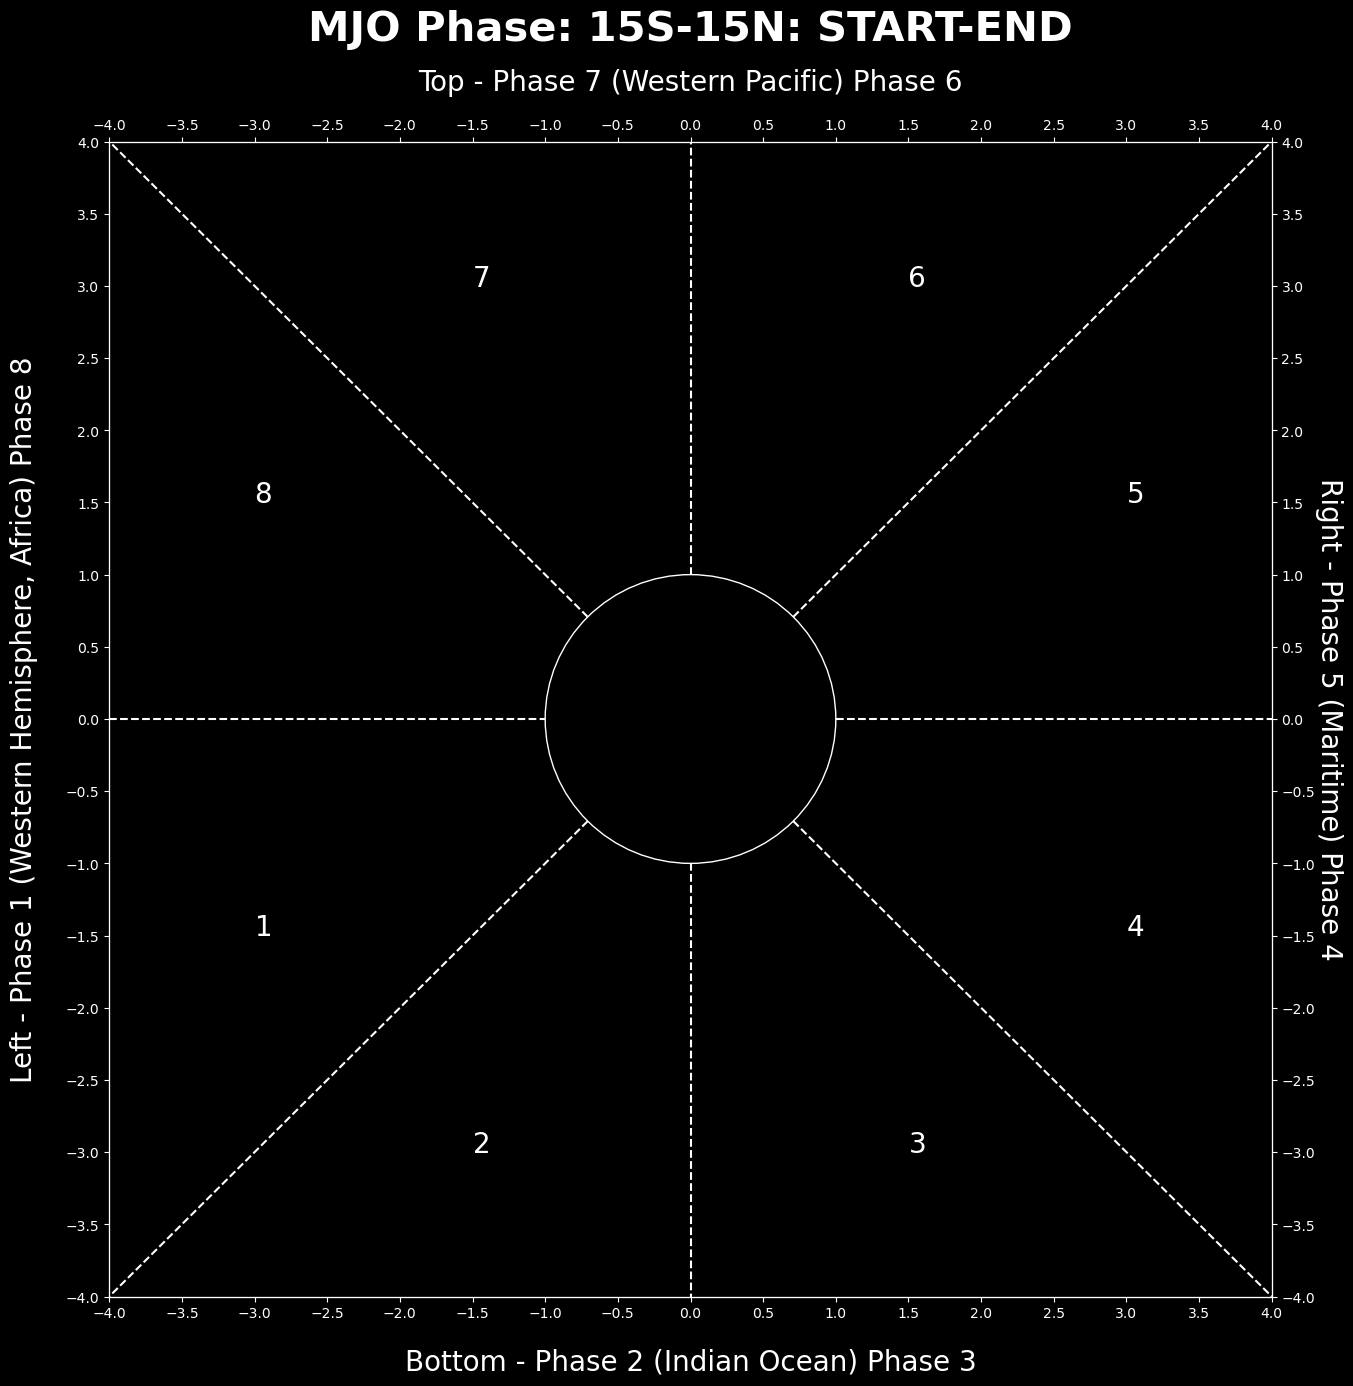

In [159]:
# Create base of the map for a Phase Diagram
# 8 Phase Divisions from -4 to 4

from matplotlib import pyplot as plt
import matplotlib.lines as lines # add phase division lines
import numpy as np

plt.style.use("dark_background") # dark mode for testing

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111)

# set x and y axis labels
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax2 = ax.twinx() 
ax3 = ax.twiny()
ax2.set_xlim(-4, 4)
ax2.set_ylim(-4, 4)
ax3.set_xlim(-4, 4)
ax3.set_ylim(-4, 4)
ax.set_xlabel("Bottom - Phase 2 (Indian Ocean) Phase 3", fontsize=20, labelpad=20)
ax.set_ylabel("Left - Phase 1 (Western Hemisphere, Africa) Phase 8", fontsize=20, labelpad=20)
ax2.set_ylabel("Right - Phase 5 (Maritime) Phase 4", fontsize=20, labelpad=20, rotation=270)
ax3.set_xlabel("Top - Phase 7 (Western Pacific) Phase 6", fontsize=20, labelpad=20)

# add amplitude circle
amplitude_circle = plt.Circle((0, 0), 1, color="white", fill=False)
ax.add_patch(amplitude_circle)

# add phase diagram lines
## Phase 1-8
phase_line = lines.Line2D([-4, -1],
                           [0, 0],
                           c="white",
                           linestyle="--")
ax.add_line(phase_line)
## Phase 1-2
phase_line = lines.Line2D([np.cos(3 * np.pi / 4), -4],
                           [np.sin(7 * np.pi / 4), -4],
                           c="white",
                           linestyle="--")
ax.add_line(phase_line)
## Phase 2-3
phase_line = lines.Line2D([0, 0],
                           [-1, -4],
                           c="white",
                           linestyle="--")
ax.add_line(phase_line)
## Phase 3-4
phase_line = lines.Line2D([np.cos(np.pi / 4), 4],
                           [np.sin(7 * np.pi / 4), -4],
                           c="white",
                           linestyle="--")
ax.add_line(phase_line)
## Phase 4-5
phase_line = lines.Line2D([1, 4],
                           [0, 0],
                           c="white",
                           linestyle="--")
ax.add_line(phase_line)
## Phase 5-6
phase_line = lines.Line2D([np.cos(np.pi / 4), 4],
                           [np.sin(np.pi / 4), 4],
                           c="white",
                           linestyle="--")
ax.add_line(phase_line)
## Phase 6-7
phase_line = lines.Line2D([0, 0],
                           [1, 4],
                           c="white",
                           linestyle="--")
ax.add_line(phase_line)
## Phase 7-8
phase_line = lines.Line2D([np.cos(3 * np.pi / 4), -4],
                           [np.sin(np.pi / 4), 4],
                           c="white",
                           linestyle="--")
ax.add_line(phase_line)

# add tick marks
full_tickmarks = np.arange(-4, 4.5, 0.5)
ax.set_xticks(full_tickmarks)
ax.set_yticks(full_tickmarks)
# hide tickmarks for top/right axis)
ax2.set_yticks(full_tickmarks)
ax3.set_xticks(full_tickmarks)

# add (optional) phase number text in each segment
ax.text(-3, -1.5, "1", color="white", fontsize=20)
ax.text(-1.5, -3, "2", color="white", fontsize=20)
ax.text(1.5, -3, "3", color="white", fontsize=20)
ax.text(3, -1.5, "4", color="white", fontsize=20)
ax.text(3, 1.5, "5", color="white", fontsize=20)
ax.text(1.5, 3, "6", color="white", fontsize=20)
ax.text(-1.5, 3, "7", color="white", fontsize=20)
ax.text(-3, 1.5, "8", color="white", fontsize=20)


# plot with title
plt.title("MJO Phase: 15S-15N: START-END", fontsize=30, fontweight="bold", pad=20)

plt.show()

# MJO 4: Create MJO Lag Plots

Via `mjo_lag_lat_lon.ncl`

# MJO 5: Calculate MJO Spectra

Via `mjo_spectra.ncl`

# MJO 6: Calculate Principle Component from EOF Analysis

Via `mjo_EOF_cal.ncl`

# MJO 7: MJO Life Cycle Composite

Via `mjo_life_cycle_v2.ncl`